# Perceptrón

### Datos linealmente separables

Se crea una grafica de dispersión para representar a 10 personas segun su edad y ahorro para ver si su tarjeta fue aprobada o denegada. Donde cada fila representa a una persona.

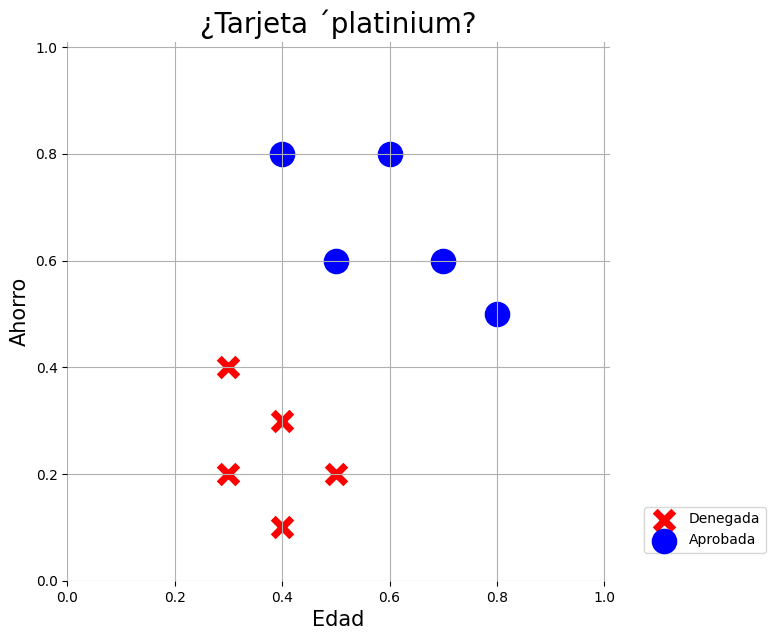

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Dato de 10 personas ->[edad, ahorro]
personas = np.array([[0.3, 0.4], [0.4, 0.3],
                    [0.3, 0.2], [0.4, 0.1],
                    [0.5, 0.2], [0.4, 0.8],
                    [0.6, 0.8], [0.5, 0.6],
                    [0.7, 0.6], [0.8, 0.5]])
clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
# Grafica (edad, ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta ´platinium?", fontsize=20)
plt.scatter (personas[clases ==0].T[0],
             personas[clases ==0].T[1],
             marker="x", s=180, color="red",
             linewidths=5, label="Denegada")
plt.scatter (personas[clases ==1].T[0],
             personas[clases ==1].T[1],
             marker="o", s=180, color="blue",
             linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
plt.grid()
plt.show()

### Funcion de Activacion (Escalón)

Aqui se implementa una neurona artificial simple, con la función de decidir si la salida sera 1 o 0 segun los valores de entrada y los pesos.

In [3]:
def activacion(pesos, x, b):
  z= pesos * x
  if z.sum()+b>0:
    return 1
  else:
    return 0
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
pesos, b, activacion(pesos, [0.5, 0.5], b)

(array([-0.3607806 , -0.72817575]), -0.3992554451164996, 0)

### Entrenamiento del Perceptrón

Se hace un entrenamiento de un perceptón con el objetivo de que la neurona aprenda a clasificar correctamente a las personas tanto aprobadas como denegadas.

In [6]:
pesos = np.random.uniform(-1, 1, size=2)
b = np.random.uniform(-1, 1)
tasa_de_aprendizaje =0.1
epocas = 100
for epoca in range(epocas):
  error_total=0
  for i in range(len(personas)):
    prediccion=activacion(pesos, personas[i], b)
    error=clases[i]-prediccion
    error_total+=error**2
    pesos[0]+=tasa_de_aprendizaje*personas[i][0]*error
    pesos[1]+=tasa_de_aprendizaje*personas[i][1]*error
    b+=tasa_de_aprendizaje*error
  print(error_total, end="")
activacion(pesos, [0.5, 0.8], b)

9977754543222322221222210000000000000000000000000000000000000000000000000000000000000000000000000000

1

### Perceptrón con Scikit-learn

Se hace uso del Perceptrón para entrenar automaticamente un modelo de clasificacion y luego realizar predicciones sobre nuevos datos. Durante el entrenamiento, el algoritmo ajusta automaticamente los pesos y el sesgo para separar las clases.

In [7]:
from sklearn.linear_model import Perceptron
perceptron=Perceptron().fit(personas, clases)
perceptron.predict([[0.2, 0.2], [0.8, 0.8]])

array([0, 1])